In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nilesh789_eurosat_rgb_path = kagglehub.dataset_download('nilesh789/eurosat-rgb')

print('Data source import complete.')


100%|██████████| 89.6M/89.6M [00:05<00:00, 17.9MB/s]

Extracting files...


Data source import complete.


In [2]:
# Importing few libraries
import os
import shutil
import random
from tqdm import tqdm

import numpy as np
import pandas as pd

import PIL
import seaborn as sns
import matplotlib.pyplot as plt

# I. Data Exploration

In this project, I'll be exploring the EUROSAT dataset. The EUROSAT dataset is composed of images taken from the Sentinel-2 satellite. This dataset lists images of the earth's surface into 10 different land cover labels. For this project, I will build an image classification model for predicting a land cover label, given an image.

In [3]:
from google.colab import files
files.upload()  # Upload kaggle.json from your Kaggle account


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jaiganesh141202","key":"fe7b6bae9de3650c290cf649953ebc48"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
!kaggle datasets download -d apollo2506/eurosat-dataset


Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0


In [7]:
!unzip -q eurosat-dataset.zip -d land_cover_dataset


In [8]:
DATASET = "/content/land_cover_dataset/EuroSAT"
LABELS = [d for d in os.listdir(DATASET) if os.path.isdir(os.path.join(DATASET, d)) and not d.startswith('.')]

print(LABELS)

['Industrial', 'AnnualCrop', 'Pasture', 'Residential', 'Highway', 'PermanentCrop', 'Forest', 'SeaLake', 'River', 'HerbaceousVegetation']


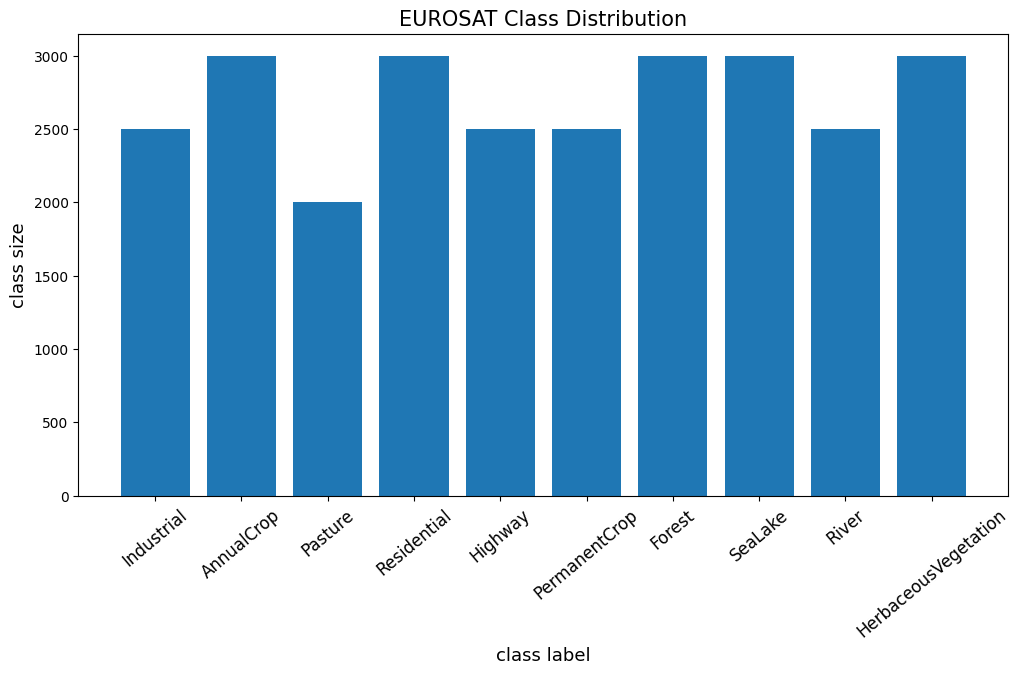

In [9]:
# plot class distributions of whole dataset
counts = {}

for l in LABELS:
    counts[l] = len(os.listdir(os.path.join(DATASET, l)))


plt.figure(figsize=(12, 6))

plt.bar(range(len(counts)), list(counts.values()), align='center')
plt.xticks(range(len(counts)), list(counts.keys()), fontsize=12, rotation=40)
plt.xlabel('class label', fontsize=13)
plt.ylabel('class size', fontsize=13)
plt.title('EUROSAT Class Distribution', fontsize=15);

The dataset is split into 10 classes of land cover. Each class varies in size, so I'll have to stratify later on when splitting the data into training, testing and validation sets.

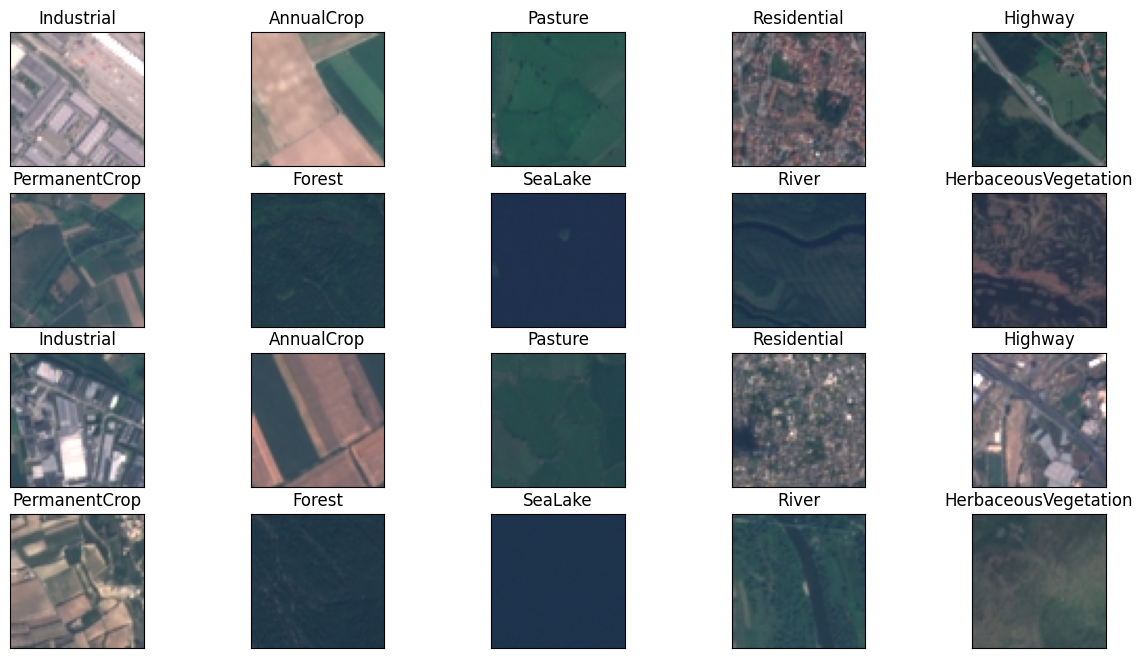

In [10]:
img_paths = [os.path.join(DATASET, l, l+'_1000.jpg') for l in LABELS]

img_paths = img_paths + [os.path.join(DATASET, l, l+'_2000.jpg') for l in LABELS]

def plot_sat_imgs(paths):
    plt.figure(figsize=(15, 8))
    for i in range(20):
        plt.subplot(4, 5, i+1, xticks=[], yticks=[])
        img = PIL.Image.open(paths[i], 'r')
        plt.imshow(np.asarray(img))
        plt.title(paths[i].split('/')[-2])

plot_sat_imgs(img_paths)

Looking at the preview of the different classes, we can see some similarities and stark differences between the classes.

Urban environments such as Highway, Residential and Industrial images all contain structures and some roadways.

AnnualCrops and PermanentCrops both feature agricultural land cover, with straight lines dilineating different crop fields.

Finally, HerbaceaousVegetation, Pasture, and Forests feature natural land cover; Rivers also could be categorized as natural land cover as well, but may be easier to distinguish from the other natural classes.

If we consider the content of each image, we might be able to estimate which classes might be confused for each other. For example, an image of a river might be mistaken for a highway. Or an image of a highway junction, with surrounding buildings, could be mistaken for an Industrial site. We'll have to train a classifier powerful enough to differentiate these nuances.

Sentinel-2 satellite images could also be downloaded with 10+ additional bands. Near-Infrared Radiation bands, for example, is a band of data that is available for this dataset. NIR can be used to create an index, visualising the radiation that is present (or not present) in a picture. This dataset does not contain the NIR wavelength bands, so this option will not be explored. But it's worth pointing out that this classification task could be addressed in another way using NIR data.

# II. Preprocessing

I'd like to evaluate the performance of the model later on after training, so I'll perform a stratified shuffle-split using Scikit-learn to maintain class proportions. 30% of the dataset will be held for evaluation purposes. I'll be loading my data into the Keras model using the ImageDataGenerator class. I'll need the images to be in their own respective land cover directories.

After splitting the dataset, I'll create some image augmentations using the generator and also denote a subset of the training data to be used as validation data during training.

In [11]:
import os
import shutil
from sklearn.model_selection import train_test_split

def split_dataset_into_train_test(original_dataset_path, output_path, split_ratio=0.3):
    labels = [d for d in os.listdir(original_dataset_path) if os.path.isdir(os.path.join(original_dataset_path, d)) and not d.startswith('.')]

    train_path = os.path.join(output_path, 'training')
    test_path = os.path.join(output_path, 'testing')

    os.makedirs(train_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    for label in labels:
        class_dir = os.path.join(original_dataset_path, label)
        images = [img for img in os.listdir(class_dir) if img.endswith('.jpg')]

        # Split the images
        train_imgs, test_imgs = train_test_split(images, test_size=split_ratio, random_state=42)

        # Create class subdirs
        os.makedirs(os.path.join(train_path, label), exist_ok=True)
        os.makedirs(os.path.join(test_path, label), exist_ok=True)

        # Move/copy train images
        for img in train_imgs:
            src = os.path.join(class_dir, img)
            dst = os.path.join(train_path, label, img)
            shutil.copy2(src, dst)

        # Move/copy test images
        for img in test_imgs:
            src = os.path.join(class_dir, img)
            dst = os.path.join(test_path, label, img)
            shutil.copy2(src, dst)

    print("✅ Dataset split done! Check:", train_path, "and", test_path)

# USAGE
original_dataset = '/content/land_cover_dataset/EuroSAT'  # or wherever your data lives
output_folder = '/content/land_cover_dataset/EuroSAT'       # will create 'training' and 'testing' inside this

split_dataset_into_train_test(original_dataset, output_folder, split_ratio=0.3)


✅ Dataset split done! Check: /content/land_cover_dataset/EuroSAT/training and /content/land_cover_dataset/EuroSAT/testing


In [ ]:
import re
from sklearn.model_selection import StratifiedShuffleSplit
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = '/content/land_cover_dataset/EuroSAT/training'
TEST_DIR = '/content/land_cover_dataset/EuroSAT/testing'
BATCH_SIZE = 64
NUM_CLASSES=len(LABELS)
INPUT_SHAPE = (64, 64, 3)
CLASS_MODE = 'categorical'

for path in (TRAIN_DIR, TEST_DIR):
    if not os.path.exists(path):
        os.mkdir(path)
        
for l in LABELS:

    if not os.path.exists(os.path.join(TRAIN_DIR, l)):
        os.mkdir(os.path.join(TRAIN_DIR, l))

    if not os.path.exists(os.path.join(TEST_DIR, l)):
        os.mkdir(os.path.join(TEST_DIR, l))

In [14]:
# Create a ImageDataGenerator Instance which can be used for data augmentation

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=60,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip = True
#   validation_split=0.2
)

train_generator = train_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    #subset='training',
    color_mode='rgb',
    shuffle=True,
    seed=69
)
# The validation set is optional if we choose to do that
"""
valid_generator = train_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    subset='validation',
    color_mode='rgb',
    shuffle=True,
    seed=69
)
"""
# test generator for evaluation purposes with no augmentations, just rescaling
test_gen = ImageDataGenerator(
    rescale=1./255,
)

test_generator = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=False,
    seed=69
)

Found 18900 images belonging to 10 classes.
Found 8100 images belonging to 10 classes.


In [15]:
print(train_generator.class_indices)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [16]:
np.save('class_indices', train_generator.class_indices)

# III. Machine Learning for Image Classification

First, we will see how a machine learning model performs by directly feeding it the whole image pixels (64x64x3 = 12288). From our 80-20 split on the 27000 samples dataset the training data is of size 21600 and test data is of size 5400. Now, here I will use some trick to utilize keras ImageDataGenerator such that we can obtain the image dataset as a numpy array which can be used by a machine learning model for training and testing.

Now, here I will test Random Forest Classifier. First by using the direct implementation provided by scikit-learn and other implemented from scratch. This notebook is a part of my course project because of which I have included this additional implementation from scratch. Feel free to check it out or you can skip over it if you want.


In [17]:
# Using image data generator api in keras for making image dataset
rf_gen = ImageDataGenerator(rescale=1./255)

rf_train_generator = rf_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(64, 64),
    # by using batch_size as training data size we can extract data from this iterator
    batch_size=21600,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=False,
    seed=7
)

rf_test_generator = rf_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=5400,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=False,
    seed=7
)

Found 18900 images belonging to 10 classes.
Found 8100 images belonging to 10 classes.


In [18]:
train = next(rf_train_generator)
X_train = train[0].reshape(train[0].shape[0], -1)
y_train = train[1]

test = next(rf_test_generator)
X_test = test[0].reshape(test[0].shape[0], -1)
y_test = test[1]



### 2. Random Forest Implementation from scratch
The dataset size is quite large (21600x12288).With scikit-learn's implementation of Random Forest we were barely able to train the model. The implementation from scratch is however not that efficient so we will only provide it with a fraction of training data. Still it can be observed that it produces reasonable accuracy considering for a 10 class classification problem a random guessing approach gives accuracy of 10%

In [ ]:
from __future__ import division
from collections import Counter
import random
import numpy as np
from scipy.stats import mode


def shuffle_in_unison(a, b):
    """ Shuffles two lists of equal length and keeps corresponding elements in the same index. """
    rng_state = np.random.get_state()
    np.random.shuffle(a)
    np.random.set_state(rng_state)
    np.random.shuffle(b)


def entropy(Y):
    """ In information theory, entropy is a measure of the uncertanty of a random sample from a group. """

    distribution = Counter(Y)
    s = 0.0
    total = len(Y)
    for y, num_y in distribution.items():
        probability_y = (num_y/total)
        s += (probability_y)*np.log(probability_y)
    return -s


def information_gain(y, y_true, y_false):
    """ The reduction in entropy from splitting data into two groups. """
    return entropy(y) - (entropy(y_true)*len(y_true) + entropy(y_false)*len(y_false))/len(y)

In [ ]:
import numpy as np
import random
from scipy.stats import mode

# Helper Functions

def entropy(y):
    """Calculates entropy of labels in y."""
    from math import log2
    labels, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def information_gain(y, y_true, y_false):
    """Computes the information gain of a split."""
    p = len(y_true) / len(y)
    return entropy(y) - (p * entropy(y_true) + (1 - p) * entropy(y_false))

def split(X, y, feature_index, threshold):
    """Splits X and y based on the binary condition xi <= threshold."""

    X_true = []
    y_true = []
    X_false = []
    y_false = []

    for j in range(len(y)):
        if X[j][feature_index] <= threshold:
            X_true.append(X[j])
            y_true.append(y[j])
        else:
            X_false.append(X[j])
            y_false.append(y[j])

    X_true = np.array(X_true)
    y_true = np.array(y_true)
    X_false = np.array(X_false)
    y_false = np.array(y_false)

    return X_true, y_true, X_false, y_false

# Node class for tree structure
class Node(object):
    def __init__(self, feature_index, threshold, branch_true, branch_false):
        self.feature_index = feature_index
        self.threshold = threshold
        self.branch_true = branch_true
        self.branch_false = branch_false

# Decision Tree Classifier
class DecisionTreeClassifier(object):
    def __init__(self, max_features=lambda x: x, max_depth=10, min_samples_split=2):
        self.max_features = max_features
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def fit(self, X, y):
        n_features = X.shape[1]
        n_sub_features = int(self.max_features(n_features))
        feature_indices = random.sample(range(n_features), n_sub_features)
        self.trunk = self.build_tree(X, y, feature_indices, 0)

    def predict(self, X):
        num_samples = X.shape[0]
        y = np.empty(num_samples)
        for j in range(num_samples):
            node = self.trunk
            while isinstance(node, Node):
                if X[j][node.feature_index] <= node.threshold:
                    node = node.branch_true
                else:
                    node = node.branch_false
            y[j] = node
        return y

    def build_tree(self, X, y, feature_indices, depth):
        if depth == self.max_depth or len(y) < self.min_samples_split or entropy(y) == 0:
            return mode(y)[0][0]

        feature_index, threshold = find_split(X, y, feature_indices)
        X_true, y_true, X_false, y_false = split(X, y, feature_index, threshold)

        if y_true.shape[0] == 0 or y_false.shape[0] == 0:
            return mode(y)[0][0]

        branch_true = self.build_tree(X_true, y_true, feature_indices, depth + 1)
        branch_false = self.build_tree(X_false, y_false, feature_indices, depth + 1)

        return Node(feature_index, threshold, branch_true, branch_false)

# Find best split based on information gain
def find_split(X, y, feature_indices):
    best_gain = 0
    best_feature_index = 0
    best_threshold = 0

    for feature_index in feature_indices:
        values = np.unique(X[:, feature_index])

        for j in range(len(values) - 1):
            threshold = (values[j] + values[j + 1]) / 2
            X_true, y_true, X_false, y_false = split(X, y, feature_index, threshold)
            gain = information_gain(y, y_true, y_false)

            if gain > best_gain:
                best_gain = gain
                best_feature_index = feature_index
                best_threshold = threshold

    return best_feature_index, best_threshold


In [ ]:
import numpy as np
from scipy.stats import mode
import random

class RandomForestClassifier(object):
    def __init__(self, n_estimators=32, max_features=np.sqrt, max_depth=10,
                 min_samples_split=2, bootstrap=0.9):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.bootstrap = bootstrap
        self.forest = []

    def fit(self, X, y):
        """Creates a forest of decision trees using a random subset of data and features."""
        self.forest = []
        n_samples = len(y)
        n_sub_samples = round(n_samples * self.bootstrap)

        for _ in range(self.n_estimators):
            # Select bootstrap sample (faster and avoids shuffling full data)
            indices = np.random.choice(n_samples, n_sub_samples, replace=True)
            X_subset = X[indices]
            y_subset = y[indices]

            tree = DecisionTreeClassifier(
                max_features=self.max_features,
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X_subset, y_subset)
            self.forest.append(tree)

    def predict(self, X):
        """Predict the class of each sample in X using majority vote from trees."""
        n_samples = X.shape[0]
        all_preds = np.zeros((len(self.forest), n_samples))

        for i, tree in enumerate(self.forest):
            all_preds[i] = tree.predict(X)

        # Return mode along axis 0 (for each sample)
        return mode(all_preds, axis=0)[0][0]

    def score(self, X, y):
        """Return the accuracy of the prediction of X compared to y."""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


In [ ]:
# Creating mini batches of training data as training on whole data is difficult
ids_2 = np.random.choice(len(X_train), size=2160, replace=False)
X_train_mini_2 = X_train[ids_2]
y_train_mini_2 = rf_train_generator.classes[ids_2]

In [ ]:
forest = RandomForestClassifier(n_estimators=2)
forest.fit(X_train_mini_2, y_train_mini_2)

In [ ]:
accuracy = forest.score(X_test, rf_test_generator.classes)
print("Accuracy Score: {0:.4}".format(accuracy))

# IV. Deep Learning For Image Classification

Deep Learning has highly influenced the field of computer vision when Convolutional Neural Networks (CNN) models were used in tasks like image classification, object detection, facial recognition etc. As discussed by authors of EuroSAT paper many deep learning models outperform the traditional non deep learning methods by a large margin.

In this section we will train many state of the art architectures which performed well on the ILSVRC challenge. The authors achieved an accuracy of 98.57% using a fine tuned ResNet50 model. Here, I will try to employ a similar strategy for training the models where initially the CNN part of the model will be frozen with imagenet weights and dense layers will be trained with a high learning rate of 0.01 and later we will train the whole model end-to-end i.e. fine tune by keeping a small learning rate between 0.001 to 0.0001

Before we start here is a list of CNN models which we will train:
1. ResNet50
2. ResNet50V2
3. ResNet152V2
3. VGG16
4. VGG19

In future
5. InceptionV3
6. Xception

we are know learning the convNext cnn model then after we will those different models

***convNext***

In [19]:
import os
import numpy as np
import torch
import torchvision.transforms as transforms
import torch.nn as nn
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import wandb
from torch.utils.data import DataLoader
import json
from torchvision.models import convnext_base,ConvNeXt_Base_Weights
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print("Found GPU")
else:
    torch.device("cpu")

print("Pytorch version:", torch.__version__)
from train_utils import get_predictions,compute_val_loss,EarlyStopping,train_model
from eval_utils import remove_wandb_hooks,evaluate_test_set,precision_recall_analysis
from EuroSAT import EurosatDataset,visualize_classes


Found GPU
Pytorch version: 2.6.0+cu124


In [20]:
# Use un-pretrained model
model = convnext_base()

# Replace the model head with the number of classes
num_classes = 10
model.classifier[2] = nn.Linear(1024, num_classes)
model.to(DEVICE)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=128, out_features=512, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=512, out_features=128, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [21]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# Paths
data_dir = "/content/land_cover_dataset/EuroSAT"
model_dir = "/content/models"
os.makedirs(model_dir, exist_ok=True)


In [22]:

project_name = "EuroSAT"
model_name = "ConvNeXt"
models_path = "content/models"

In [23]:
os.environ['WANDB_NOTEBOOK_NAME'] = 'Copy_of_Land_Cover_Classification_with_EuroSAT_Dataset.ipynb'

wandb.login()

wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find Copy_of_Land_Cover_Classification_with_EuroSAT_Dataset.ipynb.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jaiganesh170621 (jaiganesh170621-nit-andhra-pradesh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import wandb
from tqdm import tqdm
import os
import numpy as np


def train_model(model, epochs, train_loader, valid_loader, model_name, lr, patience, device, model_save_path):
    """
    Trains a PyTorch model and logs training progress using wandb, including accuracy.

    Args:
        model (torch.nn.Module): The model to train.
        epochs (int): The number of training epochs.
        train_loader (torch.utils.data.DataLoader): Data loader for the training dataset.
        valid_loader (torch.utils.data.DataLoader): Data loader for the validation dataset.
        model_name (str): Name of the model.
        lr (float): Learning rate.
        patience (int): Early stopping patience.
        device (torch.device): Device to train the model on (CPU or GPU).
        model_save_path (str): Directory to save the model checkpoints.

    Returns:
        Tuple[List[float], List[float]]: Training and validation loss history.
    """

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_i = []
    loss_val_i = []
    best_loss = np.inf
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_train = 0
        total_train = 0
        progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{epochs}")

        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

            progress_bar.set_postfix({"Loss": loss.item()})

        avg_loss = total_loss / len(train_loader)
        train_accuracy = 100.0 * correct_train / total_train
        loss_i.append(avg_loss)

        # Validation
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / len(valid_loader)
        val_accuracy = 100.0 * correct_val / total_val
        loss_val_i.append(avg_val_loss)

        wandb.log({
            "Epoch": epoch + 1,
            "Training Loss": avg_loss,
            "Validation Loss": avg_val_loss,
            "Training Accuracy": train_accuracy,
            "Validation Accuracy": val_accuracy
        })

        print(f"Epoch {epoch+1}: Train Loss: {avg_loss:.4f}, Train Acc: {train_accuracy:.2f}%, "
              f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        # Early stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), os.path.join(model_save_path, f"{model_name}_best.pth"))
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs.")
                break

    return loss_i, loss_val_i


In [25]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image

In [30]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image

class EuroSATDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.image_paths = []
        self.labels = []

        for cls in self.classes:
            class_dir = os.path.join(root_dir, cls)
            for image_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir, image_name)
                self.image_paths.append(image_path)
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(64),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(64),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create datasets
train_dataset = EuroSATDataset(root_dir=TRAIN_DIR, transform=data_transforms['train'])
valid_dataset = EuroSATDataset(root_dir=TEST_DIR, transform=data_transforms['val']) # Using TEST_DIR for validation

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=train_batch, shuffle=False) # Using same batch size as train_loader

In [29]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image

class EuroSATDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.image_paths = []
        self.labels = []

        for cls in self.classes:
            class_dir = os.path.join(root_dir, cls)
            for image_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir, image_name)
                self.image_paths.append(image_path)
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(64),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(64),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create datasets
train_dataset = EuroSATDataset(root_dir=TRAIN_DIR, transform=data_transforms['train'])
valid_dataset = EuroSATDataset(root_dir=TEST_DIR, transform=data_transforms['val']) # Using TEST_DIR for validation

# Define train_batch before using it
train_batch = 64 # You can set this to your desired batch size

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=train_batch, shuffle=False) # Using same batch size as train_loader

In [33]:
import os

project_name = "EuroSAT"
model_name = "ConvNeXt"
models_path = "content/models"  # Make sure this path matches what you're passing later

# 🔧 Fix: create the models directory if not there
os.makedirs(models_path, exist_ok=True)

# Define 'patience' before using it
patience = 5  # You can adjust this value as needed

# init W&B
run = wandb.init(
    project=project_name,
    name=model_name,
    notes="ConvNeXt from scratch",
    config={
        "learning_rate": 1e-3,
        "epochs": 10,
        "batch_size": train_batch,  # Assuming train_batch is defined
        "patience": patience
    }
)

# ✅ Now train the model
loss_i, loss_val_i = train_model(
    model=model,
    epochs=10,
    train_loader=train_loader,
    valid_loader=valid_loader,
    model_name=model_name,
    lr=1e-3,  # Assuming lr is defined
    patience=patience,
    device=DEVICE,  # Assuming DEVICE is defined
    model_save_path=models_path  # This now points to an existing folder
)

Training Epoch 1/10: 100%|██████████| 296/296 [01:47<00:00,  2.76it/s, Loss=1.39]


Epoch 1: Train Loss: 1.7687, Train Acc: 36.69%, Val Loss: 1.3392, Val Acc: 53.53%


Training Epoch 2/10: 100%|██████████| 296/296 [01:45<00:00,  2.82it/s, Loss=1.36]


Epoch 2: Train Loss: 1.2523, Train Acc: 54.74%, Val Loss: 1.1403, Val Acc: 60.21%


Training Epoch 3/10: 100%|██████████| 296/296 [01:45<00:00,  2.81it/s, Loss=0.771]


...

Epoch 8: Train Loss: 0.6555, Train Acc: 77.63%, Val Loss: 0.6297, Val Acc: 78.36%


Training Epoch 9/10: 100%|██████████| 296/296 [01:45<00:00,  2.81it/s, Loss=0.956]


Epoch 9: Train Loss: 0.6430, Train Acc: 77.83%, Val Loss: 0.5853, Val Acc: 79.28%


Training Epoch 10/10: 100%|██████████| 296/296 [01:44<00:00,  2.82it/s, Loss=0.819]


Epoch 10: Train Loss: 0.6084, Train Acc: 78.98%, Val Loss: 0.5340, Val Acc: 81.09%


In [34]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as file:
    file.write(f"loss_i: {loss_i}\n")
    file.write(f"loss_val_i: {loss_val_i}\n")

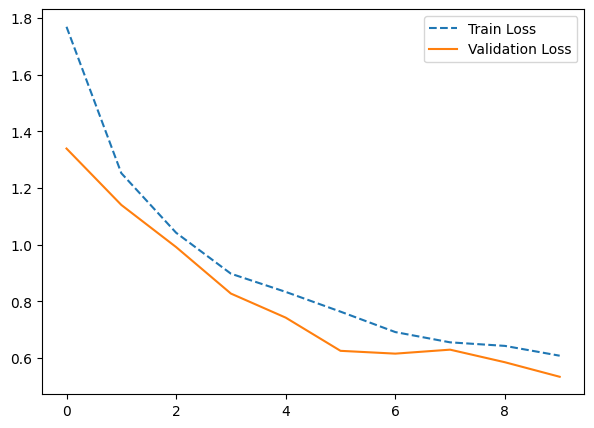

In [35]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()


In [36]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + f"{model_name}_best_model.pth"
print(f"Loading model {model_save_path}")
model_save_path = models_path + f"{model_name}_best_model.pth"

Loading model content/modelsConvNeXt_best_model.pth


In [37]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image
# %%
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image

class EuroSATDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.image_paths = []
        self.labels = []

        for cls in self.classes:
            class_dir = os.path.join(root_dir, cls)
            for image_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir, image_name)
                self.image_paths.append(image_path)
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(64),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(64),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create datasets
train_dataset = EuroSATDataset(root_dir=TRAIN_DIR, transform=data_transforms['train'])
valid_dataset = EuroSATDataset(root_dir=TEST_DIR, transform=data_transforms['val']) # Using TEST_DIR for validation

# Create data loaders
# Assuming train_batch is a global variable
train_batch = 64  # Or whatever your batch size is
train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)
test_loader = DataLoader(valid_dataset, batch_size=train_batch, shuffle=False) # Using same batch size as train_loader

# Get class labels from train_dataset or define them explicitly
index_to_label = {v: k for k, v in train_dataset.class_to_idx.items()} # If train_dataset has class_to_idx
# or
# index_to_label = {0: 'label1', 1: 'label2', ...} # Manually define the labels

In [ ]:
evaluate_test_set(model, test_loader, DEVICE, index_to_label=index_to_label)

Evaluating on Test Set: 100%|██████████| 127/127 [00:10<00:00, 11.63it/s]

                      precision    recall  f1-score   support

          AnnualCrop       0.85      0.86      0.86       900
              Forest       0.87      0.97      0.91       900
HerbaceousVegetation       0.88      0.72      0.79       900
             Highway       0.73      0.63      0.68       750
          Industrial       0.76      0.96      0.85       750
             Pasture       0.72      0.88      0.79       600
       PermanentCrop       0.68      0.80      0.74       750
         Residential       0.80      0.88      0.84       900
               River       0.82      0.61      0.70       750
             SeaLake       1.00      0.78      0.87       900

            accuracy                           0.81      8100
           macro avg       0.81      0.81      0.80      8100
        weighted avg       0.82      0.81      0.81      8100



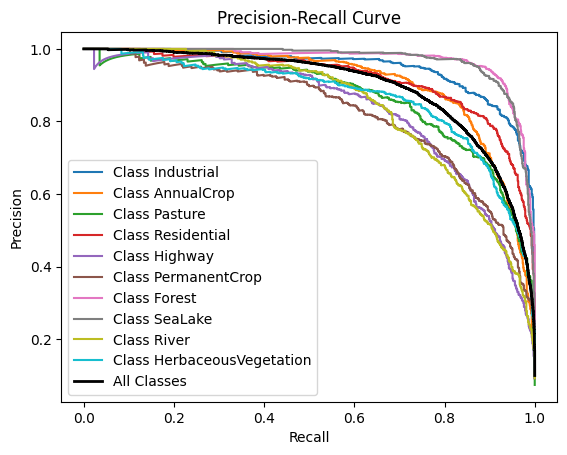

In [42]:
precision_recall_analysis(model, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [41]:
def precision_recall_analysis(model, test_loader, device, output_path, model_name, index_to_label):
    """
    Evaluates a given model on the test dataset and generates precision-recall curves for each class
    and all classes combined. It also saves these values to a JSON file.

    Parameters:
    -----------
    model : torch.nn.Module
        The neural network model to be evaluated.

    test_loader : torch.utils.data.DataLoader
        DataLoader containing the test dataset.

    device : torch.device
        The device (CPU or GPU) to run the model on.

    output_path : str
        The path where the output JSON file will be saved.

    model_name : str
        The name of the model, used for naming the output JSON file.

    index_to_label : dict
        A dictionary mapping class indices to their respective labels.

    Returns:
    --------
    None
        This function does not return anything. It saves the precision-recall data to a JSON file
        and displays the precision-recall curves.

    Notes:
    ------
    - This function requires the model to be in evaluation mode.
    - It disables gradient computation during evaluation to save memory.
    - It assumes that the inputs are 4D tensors, with the color channel as the last dimension.

    Raises:
    -------
    FileNotFoundError
        If the specified output path is not found.
    """

    # Set the model to evaluation mode
    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():  # Disable gradient computation
        for data in test_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # Remove or correct the permutation
            # inputs = inputs.permute(0, 3, 1, 2).type(torch.cuda.FloatTensor)
            # The line above was causing the issue, likely due to unnecessary permutation.
            # Assuming your images are already in the correct format (C, H, W)
            outputs = model(inputs)
            probs = nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels_one_hot = np.eye(len(index_to_label))[all_labels]

    precision_recall_data = {}

    # Precision-Recall curve for each class
    for i, label in enumerate(index_to_label.values()):
        precision, recall, _ = precision_recall_curve(all_labels_one_hot[:, i], all_probs[:, i])
        plt.plot(recall, precision, label=f'Class {label}')

    # Precision-Recall curve for all classes
    precision, recall, _ = precision_recall_curve(all_labels_one_hot.ravel(), all_probs.ravel())
    plt.plot(recall, precision, label='All Classes', color='black', lw=2)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='best')
    plt.show()

    # Save precision and recall for all classes
    precision_recall_data['All Classes'] = {'precision': precision.tolist(), 'recall': recall.tolist()}

    # Save the data to a JSON file
    filename = f"{model_name}_precision_recall_values.json"
    output_path = os.path.join(output_path, filename)
    with open(output_path, 'w') as json_file:
        json.dump(precision_recall_data, json_file, indent=4)

convNeXt is completed


In [47]:
import tensorflow as tf
from keras.models import Model
from keras.layers import Dense, Dropout, Flatten
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam


from keras.applications import VGG16, VGG19
from keras.applications import ResNet50, ResNet50V2, ResNet152V2
from keras.applications import InceptionV3, Xception

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, fbeta_score, accuracy_score

In [44]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  # Restrict TensorFlow to only use the first GPU
  try:
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPU")
  except RuntimeError as e:
    # Visible devices must be set before GPUs have been initialized
    print(e)

tf.config.set_soft_device_placement(True)

1 Physical GPUs, 1 Logical GPU


In [45]:
# Note that for different CNN models we are using different setup of dense layers
def compile_model(cnn_base, input_shape, n_classes, optimizer, fine_tune=None):

    if (cnn_base == 'ResNet50') or (cnn_base == 'ResNet50V2') or (cnn_base == 'ResNet152V2'):
        if cnn_base == 'ResNet50':
            conv_base = ResNet50(include_top=False,
                                 weights='imagenet',
                                 input_shape=input_shape)
        elif cnn_base == 'ResNet50V2':
            conv_base = ResNet50V2(include_top=False,
                                 weights='imagenet',
                                 input_shape=input_shape)
        else:
            conv_base = ResNet152V2(include_top=False,
                                 weights='imagenet',
                                 input_shape=input_shape)
        top_model = conv_base.output
        top_model = Flatten()(top_model)
        top_model = Dense(2048, activation='relu')(top_model)
        top_model = Dropout(0.2)(top_model)


    elif (cnn_base == 'VGG16') or (cnn_base == 'VGG19'):
        if cnn_base == 'VGG16':
            conv_base = VGG16(include_top=False,
                              weights='imagenet',
                              input_shape=input_shape)
        else:
            conv_base = VGG19(include_top=False,
                              weights='imagenet',
                              input_shape=input_shape)
        top_model = conv_base.output
        top_model = Flatten()(top_model)
        top_model = Dense(2048, activation='relu')(top_model)
        top_model = Dropout(0.2)(top_model)
        top_model = Dense(2048, activation='relu')(top_model)
        top_model = Dropout(0.2)(top_model)


    output_layer = Dense(n_classes, activation='softmax')(top_model)

    model = Model(inputs=conv_base.input, outputs=output_layer)

    if type(fine_tune) == int:
        for layer in conv_base.layers[fine_tune:]:
            layer.trainable = True
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    model.compile(optimizer=optimizer, loss='categorical_crossentropy',
                 metrics=['categorical_accuracy'])

    return model

def plot_history(history):

    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc)
    plt.plot(val_acc)
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(loss)
    plt.plot(val_loss)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')

    plt.show();

def display_results(y_true, y_preds, class_labels):

    results = pd.DataFrame(precision_recall_fscore_support(y_true, y_preds),
                          columns=class_labels).T
    results.rename(columns={0: 'Precision',
                           1: 'Recall',
                           2: 'F-Score',
                           3: 'Support'}, inplace=True)

    conf_mat = pd.DataFrame(confusion_matrix(y_true, y_preds),
                            columns=class_labels,
                            index=class_labels)
    f2 = fbeta_score(y_true, y_preds, beta=2, average='micro')
    accuracy = accuracy_score(y_true, y_preds)
    print(f"Accuracy: {accuracy}")
    print(f"Global F2 Score: {f2}")
    return results, conf_mat

def plot_predictions(y_true, y_preds, test_generator, class_indices):

    fig = plt.figure(figsize=(20, 10))
    for i, idx in enumerate(np.random.choice(test_generator.samples, size=20, replace=False)):
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(test_generator[idx]))
        pred_idx = np.argmax(y_preds[idx])
        true_idx = y_true[idx]

        plt.tight_layout()
        ax.set_title("{}\n({})".format(class_indices[pred_idx], class_indices[true_idx]),
                     color=("green" if pred_idx == true_idx else "red"))

In [46]:
N_STEPS = train_generator.samples//BATCH_SIZE
N_VAL_STEPS = test_generator.samples//BATCH_SIZE
N_EPOCHS = 100

# model callbacks
checkpoint = ModelCheckpoint(filepath='../working/model.weights.best.h5', # Changed the file extension from .hdf5 to .h5
                        monitor='val_categorical_accuracy',
                        save_best_only=True,
                        verbose=1)


early_stop = EarlyStopping(monitor='val_categorical_accuracy',
                           patience=10,
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.5,
                              patience=3, min_lr=0.00001)

## 4.1 ResNet50 Model

In [ ]:
resnet50_model = compile_model('ResNet50', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-2), fine_tune=None) # Changed lr to learning_rate
resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 70, 70, 3)      │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 32, 32, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 32, 32, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 32, 32, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 34, 34, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 16, 16, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 16, 16, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 16, 16, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 16, 16, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 16, 16, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 16, 16, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 16, 16, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 16, 16, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 16, 16, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 40,391,564 (154.08 MB)

 Trainable params: 16,803,852 (64.10 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
train_generator.reset()
test_generator.reset()

N_STEPS = train_generator.samples//BATCH_SIZE
N_VAL_STEPS = test_generator.samples//BATCH_SIZE
N_EPOCHS = 100

# model callbacks
checkpoint = ModelCheckpoint(filepath='../working/model.weights.best.h5',
                        monitor='val_categorical_accuracy',
                        save_best_only=True,
                        verbose=1)

early_stop = EarlyStopping(monitor='val_categorical_accuracy',
                           patience=10,
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.5,
                              patience=3, min_lr=0.00001)

In [ ]:
# First Pretraining the dense layer
resnet50_history = resnet50_model.fit(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=10,
                             callbacks=[early_stop, checkpoint],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

Epoch 1/10
  5/295 ━━━━━━━━━━━━━━━━━━━━ 3:48 789ms/step - categorical_accuracy: 0.3017 - loss: 1.7406

KeyboardInterrupt: 

In [ ]:
# re-train whole network end2end
resnet50_model = compile_model('ResNet50', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-4), fine_tune=0)

resnet50_model.load_weights('../working/model.weights.best.h5')

train_generator.reset()
test_generator.reset()

resnet50_history = resnet50_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=N_EPOCHS,
                             callbacks=[early_stop, checkpoint, reduce_lr],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

AttributeError: 'Functional' object has no attribute 'fit_generator'

In [ ]:
# re-train whole network end2end
resnet50_model = compile_model('ResNet50', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-4), fine_tune=0)

resnet50_model.load_weights('../working/model.weights.best.h5')

train_generator.reset()
test_generator.reset()

# Use model.fit instead of model.fit_generator
resnet50_history = resnet50_model.fit(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=N_EPOCHS,
                             callbacks=[early_stop, checkpoint, reduce_lr],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

Epoch 1/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - categorical_accuracy: 0.6460 - loss: 2.6263
Epoch 1: val_categorical_accuracy did not improve from 0.43973
295/295 ━━━━━━━━━━━━━━━━━━━━ 1999s 7s/step - categorical_accuracy: 0.6464 - loss: 2.6211 - val_categorical_accuracy: 0.1102 - val_loss: 71.9471 - learning_rate: 1.0000e-04
Epoch 2/100
  1/295 ━━━━━━━━━━━━━━━━━━━━ 36:36 7s/step - categorical_accuracy: 0.7812 - loss: 0.5591

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_categorical_accuracy did not improve from 0.43973
295/295 ━━━━━━━━━━━━━━━━━━━━ 83s 258ms/step - categorical_accuracy: 0.7812 - loss: 0.5591 - val_categorical_accuracy: 0.1102 - val_loss: 72.1646 - learning_rate: 1.0000e-04
Epoch 3/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - categorical_accuracy: 0.8884 - loss: 0.3445
Epoch 3: val_categorical_accuracy did not improve from 0.43973
295/295 ━━━━━━━━━━━━━━━━━━━━ 2000s 7s/step - categorical_accuracy: 0.8884 - loss: 0.3444 - val_categorical_accuracy: 0.1152 - val_loss: 18.3754 - learning_rate: 1.0000e-04
Epoch 4/100
  1/295 ━━━━━━━━━━━━━━━━━━━━ 31:04 6s/step - categorical_accuracy: 0.7969 - loss: 0.5453
Epoch 4: val_categorical_accuracy did not improve from 0.43973
295/295 ━━━━━━━━━━━━━━━━━━━━ 81s 255ms/step - categorical_accuracy: 0.7969 - loss: 0.5453 - val_categorical_accuracy: 0.1148 - val_loss: 18.4833 - learning_rate: 1.0000e-04
Epoch 5/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - categorical_accuracy: 0.9175 - loss: 0.

295/295 ━━━━━━━━━━━━━━━━━━━━ 2072s 7s/step - categorical_accuracy: 0.9369 - loss: 0.1933 - val_categorical_accuracy: 0.9046 - val_loss: 0.3410 - learning_rate: 1.0000e-04
Epoch 8/100
  1/295 ━━━━━━━━━━━━━━━━━━━━ 30:04 6s/step - categorical_accuracy: 0.9062 - loss: 0.2510
Epoch 8: val_categorical_accuracy did not improve from 0.90464
295/295 ━━━━━━━━━━━━━━━━━━━━ 130s 420ms/step - categorical_accuracy: 0.9062 - loss: 0.2510 - val_categorical_accuracy: 0.9045 - val_loss: 0.3413 - learning_rate: 1.0000e-04
Epoch 9/100
117/295 ━━━━━━━━━━━━━━━━━━━━ 19:17 7s/step - categorical_accuracy: 0.9388 - loss: 0.1731

In [ ]:
plot_history(resnet50_history)

In [ ]:
resnet50_model.load_weights('../working/model.weights.best.hdf5')

class_indices = train_generator.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

test_generator_new = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=1,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,
    seed=69
)

predictions = resnet50_model.predict_generator(test_generator_new, steps=len(test_generator_new.filenames))
predicted_classes = np.argmax(np.rint(predictions), axis=1)
true_classes = test_generator_new.classes

prf, conf_mat = display_results(true_classes, predicted_classes, class_indices.values())
prf

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../working/model.weights.best.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# Save the model and the weights
resnet50_model.save('../working/ResNet50_eurosat.h5')

## 4.2 ResNet50V2 Model

In [ ]:
resnet50V2_model = compile_model('ResNet50V2', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-2), fine_tune=None)
resnet50V2_model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 64, 64, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 70, 70, 3)      │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 32, 32, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 34, 34, 64)     │              0 │ conv1_conv[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 16, 16, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_bn    │ (None, 16, 16, 64)     │            256 │ pool1_pool[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_relu  │ (None, 16, 16, 64)     │              0 │ conv2_block1_preact_b… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 16, 16, 64)     │          4,096 │ conv2_block1_preact_r… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 16, 16, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 16, 16, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_pad        │ (None, 18, 18, 64)     │              0 │ conv2_block1_1_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 16, 16, 64)     │         36,864 │ conv2_block1_2_pad[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 16, 16, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 16, 16, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv  

 Total params: 40,368,652 (153.99 MB)

 Trainable params: 16,803,852 (64.10 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
train_generator.reset()
test_generator.reset()

N_STEPS = train_generator.samples//BATCH_SIZE
N_VAL_STEPS = test_generator.samples//BATCH_SIZE
N_EPOCHS = 100

# model callbacks
checkpoint = ModelCheckpoint(filepath='../working/model.weights.best.hdf5',
                        monitor='val_categorical_accuracy',
                        save_best_only=True,
                        verbose=1)

early_stop = EarlyStopping(monitor='val_categorical_accuracy',
                           patience=10,
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.5,
                              patience=3, min_lr=0.00001)

In [ ]:
# First Pretraining the dense layer
resnet50V2_history = resnet50V2_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=50,
                             callbacks=[early_stop, checkpoint],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
# re-train whole network end2end
resnet50V2_model = compile_model('ResNet50V2', INPUT_SHAPE, NUM_CLASSES, Adam(lr=1e-4), fine_tune=0)

resnet50V2_model.load_weights('../working/model.weights.best.hdf5')

train_generator.reset()
test_generator.reset()

resnet50V2_history = resnet50V2_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=N_EPOCHS,
                             callbacks=[early_stop, checkpoint, reduce_lr],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
plot_history(resnet50V2_history)

In [ ]:
resnet50V2_model.load_weights('../working/model.weights.best.hdf5')

class_indices = train_generator.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

test_generator_new = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=1,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,
    seed=69
)

predictions = resnet50V2_model.predict_generator(test_generator_new, steps=len(test_generator_new.filenames))
predicted_classes = np.argmax(np.rint(predictions), axis=1)
true_classes = test_generator_new.classes

prf, conf_mat = display_results(true_classes, predicted_classes, class_indices.values())
prf

In [ ]:
# Save the model and the weights
resnet50V2_model.save('../working/ResNet50V2_eurosat.h5')

## 4.3 ResNet152V2 Model

In [ ]:
resnet152V2_model = compile_model('ResNet152V2', INPUT_SHAPE, NUM_CLASSES, Adam(lr=1e-2), fine_tune=None)
resnet152V2_model.summary()

In [ ]:
train_generator.reset()
test_generator.reset()

N_STEPS = train_generator.samples//BATCH_SIZE
N_VAL_STEPS = test_generator.samples//BATCH_SIZE
N_EPOCHS = 100

# model callbacks
checkpoint = ModelCheckpoint(filepath='../working/model.weights.best.hdf5',
                        monitor='val_categorical_accuracy',
                        save_best_only=True,
                        verbose=1)

early_stop = EarlyStopping(monitor='val_categorical_accuracy',
                           patience=10,
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.5,
                              patience=3, min_lr=0.00001)

In [ ]:
# First Pretraining the dense layer
resnet152V2_history = resnet152V2_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=50,
                             callbacks=[early_stop, checkpoint],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
# re-train whole network end2end
resnet152V2_model = compile_model('ResNet152V2', INPUT_SHAPE, NUM_CLASSES, Adam(lr=1e-4), fine_tune=0)

resnet152V2_model.load_weights('../working/model.weights.best.hdf5')

train_generator.reset()
test_generator.reset()

resnet152V2_history = resnet152V2_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=N_EPOCHS,
                             callbacks=[early_stop, checkpoint, reduce_lr],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
plot_history(resnet152V2_history)

In [ ]:
resnet152V2_model.load_weights('../working/model.weights.best.hdf5')

class_indices = train_generator.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

test_generator_new = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=1,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,
    seed=69
)

predictions = resnet152V2_model.predict_generator(test_generator_new, steps=len(test_generator_new.filenames))
predicted_classes = np.argmax(np.rint(predictions), axis=1)
true_classes = test_generator_new.classes

prf, conf_mat = display_results(true_classes, predicted_classes, class_indices.values())
prf

In [ ]:
# Save the model and the weights
resnet152V2_model.save('../working/ResNet152V2_eurosat.h5')

## 4.4 VGG16 Model

In [ ]:
vgg16_model = compile_model('VGG16', INPUT_SHAPE, NUM_CLASSES, Adam(lr=1e-2), fine_tune=None)
vgg16_model.summary()

In [ ]:
train_generator.reset()
test_generator.reset()

N_STEPS = train_generator.samples//BATCH_SIZE
N_VAL_STEPS = test_generator.samples//BATCH_SIZE
N_EPOCHS = 100

# model callbacks
checkpoint = ModelCheckpoint(filepath='../working/model.weights.best.hdf5',
                        monitor='val_categorical_accuracy',
                        save_best_only=True,
                        verbose=1)

early_stop = EarlyStopping(monitor='val_categorical_accuracy',
                           patience=10,
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.5,
                              patience=3, min_lr=0.00001)

In [ ]:
train_generator.reset()
# First Pretraining the dense layer
vgg16_history = vgg16_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=50,
                             callbacks=[early_stop, checkpoint],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
# re-train whole network end2end
vgg16_model = compile_model('VGG16', INPUT_SHAPE, NUM_CLASSES, Adam(lr=1e-4), fine_tune=0)

vgg16_model.load_weights('../working/model.weights.best.hdf5')

train_generator.reset()
test_generator.reset()

vgg16_history = vgg16_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=N_EPOCHS,
                             callbacks=[early_stop, checkpoint, reduce_lr],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
plot_history(vgg16_history)

In [ ]:
vgg16_model.load_weights('../working/model.weights.best.hdf5')

class_indices = train_generator.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

test_generator_new = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=1,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,
    seed=69
)

predictions = vgg16_model.predict_generator(test_generator_new, steps=len(test_generator_new.filenames))
predicted_classes = np.argmax(np.rint(predictions), axis=1)
true_classes = test_generator_new.classes

prf, conf_mat = display_results(true_classes, predicted_classes, class_indices.values())
prf

In [ ]:
# Save the model and the weights
vgg16_model.save('../working/vgg16_eurosat.h5')

## 4.5 VGG19 Model

In [ ]:
vgg19_model = compile_model('VGG19', INPUT_SHAPE, NUM_CLASSES, Adam(lr=1e-2), fine_tune=None)
vgg19_model.summary()

In [ ]:
train_generator.reset()
test_generator.reset()

N_STEPS = train_generator.samples//BATCH_SIZE
N_VAL_STEPS = test_generator.samples//BATCH_SIZE
N_EPOCHS = 100

# model callbacks
checkpoint = ModelCheckpoint(filepath='../working/model.weights.best.hdf5',
                        monitor='val_categorical_accuracy',
                        save_best_only=True,
                        verbose=1)

early_stop = EarlyStopping(monitor='val_categorical_accuracy',
                           patience=10,
                           restore_best_weights=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.5,
                              patience=3, min_lr=0.00001)

In [ ]:
train_generator.reset()
# First Pretraining the dense layer
vgg19_history = vgg19_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=50,
                             callbacks=[early_stop, checkpoint],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
# re-train whole network end2end
vgg19_model = compile_model('VGG19', INPUT_SHAPE, NUM_CLASSES, Adam(lr=1e-4), fine_tune=0)

vgg19_model.load_weights('../working/model.weights.best.hdf5')

train_generator.reset()
test_generator.reset()

vgg19_history = vgg19_model.fit_generator(train_generator,
                             steps_per_epoch=N_STEPS,
                             epochs=N_EPOCHS,
                             callbacks=[early_stop, checkpoint, reduce_lr],
                             validation_data=test_generator,
                             validation_steps=N_VAL_STEPS)

In [ ]:
plot_history(vgg19_history)

In [ ]:
vgg19_model.load_weights('../working/model.weights.best.hdf5')

class_indices = train_generator.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

test_generator_new = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(64, 64),
    batch_size=1,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,
    seed=69
)

predictions = vgg19_model.predict_generator(test_generator_new, steps=len(test_generator_new.filenames))
predicted_classes = np.argmax(np.rint(predictions), axis=1)
true_classes = test_generator_new.classes

prf, conf_mat = display_results(true_classes, predicted_classes, class_indices.values())
prf

In [ ]:
# Save the model and the weights
vgg19_model.save('../working/vgg19_eurosat.h5')

In [ ]:
plot_predictions(true_classes, predictions, test_generator_new, class_indices)